# 01 — Initial EDA on PaySim Transaction Data

Exploratory analysis of the class imbalance, transaction-type distribution,
and amount/balance patterns that motivate the modeling choices in this
project (see `README.md` and the literature review for context).

**Note:** if `data/raw/` only contains the synthetic sample
(`sample_paysim.csv` from `src/data/generate_sample.py`), the numbers below
are illustrative only — swap in the real PaySim CSV for the actual analysis.

In [1]:
import sys
sys.path.append("..")

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from src.data.load_data import load_paysim, summarize

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

df = load_paysim()
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,CASH-IN,"10,887.53",C1914545636,"19,177.35","8,289.82",C4956492136,"32,990.75","43,878.28",0,0
1,1,TRANSFER,"4,465.57",C8870485276,"13,656.96","9,191.39",C8710567039,"46,441.78","50,907.35",0,0
2,1,CASH-IN,"6,363.03",C4649917181,"12,022.42","5,659.39",C3420877123,"25,874.68","32,237.71",0,0
3,1,PAYMENT,"1,326.99",C1985467645,"30,213.59","28,886.60",C1176909563,369.45,"1,696.44",0,0
4,1,TRANSFER,"22,621.50",C4631249288,"2,543.04",0.00,C3733093200,"23,723.50","46,345.00",0,0


## 1. Class imbalance

The central challenge named in the literature review: fraud is rare.

Rows: 20,000
Fraudulent: 11 (0.0550%)


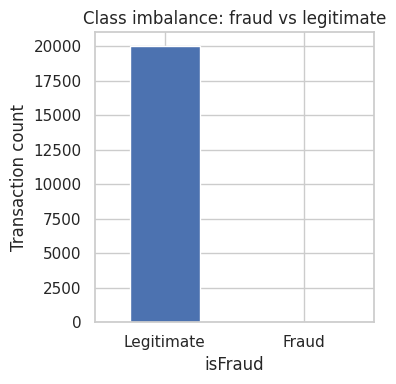

In [2]:
stats = summarize(df)
print(f"Rows: {stats['n_rows']:,}")
print(f"Fraudulent: {stats['n_fraud']:,} ({stats['fraud_rate']:.4%})")

fig, ax = plt.subplots(figsize=(4, 4))
df["isFraud"].value_counts().plot(kind="bar", ax=ax, color=["#4C72B0", "#C44E52"])
ax.set_xticklabels(["Legitimate", "Fraud"], rotation=0)
ax.set_ylabel("Transaction count")
ax.set_title("Class imbalance: fraud vs legitimate")
plt.tight_layout()
plt.savefig("../reports/figures/class_imbalance.png", dpi=150)
plt.show()

## 2. Transaction type distribution

Real-world PaySim fraud is concentrated in `TRANSFER` and `CASH-OUT` transactions only.

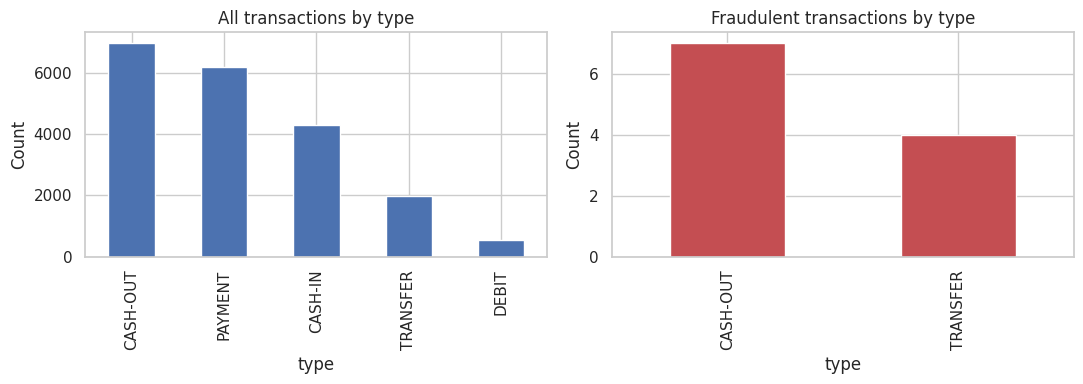

type
CASH-OUT    7
TRANSFER    4
Name: count, dtype: int64

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

df["type"].value_counts().plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_title("All transactions by type")
axes[0].set_ylabel("Count")

fraud_by_type = df[df["isFraud"] == 1]["type"].value_counts()
fraud_by_type.plot(kind="bar", ax=axes[1], color="#C44E52")
axes[1].set_title("Fraudulent transactions by type")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig("../reports/figures/transaction_type_distribution.png", dpi=150)
plt.show()

fraud_by_type

## 3. Transaction amount distribution

Fraudulent vs legitimate transaction amounts (log scale, since amounts are heavily right-skewed).

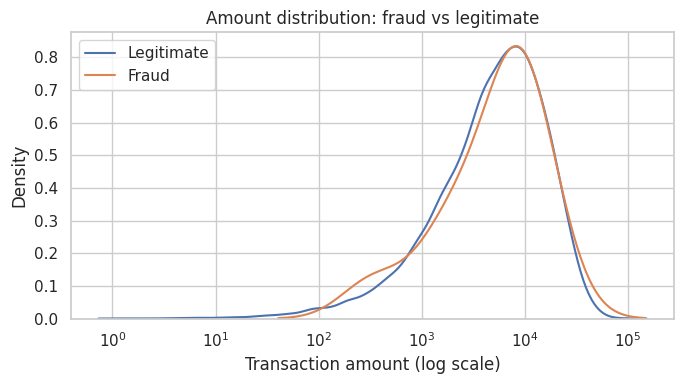

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
for label, group in df.groupby("isFraud"):
    sns.kdeplot(group["amount"].clip(lower=1), log_scale=True, ax=ax,
                label="Fraud" if label == 1 else "Legitimate")
ax.set_xlabel("Transaction amount (log scale)")
ax.set_title("Amount distribution: fraud vs legitimate")
ax.legend()
plt.tight_layout()
plt.savefig("../reports/figures/amount_distribution.png", dpi=150)
plt.show()

## 4. Origin-account balance discrepancy

A recurring signal in PaySim fraud analysis: for many fraudulent transactions,
`newbalanceOrig` doesn't equal `oldbalanceOrg - amount` as it should, and the
origin account is often fully drained. This engineered discrepancy feature
becomes an input to the Bayesian model in a later step.

/tmp/ipykernel_551/1100161374.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Legitimate", "Fraud"])


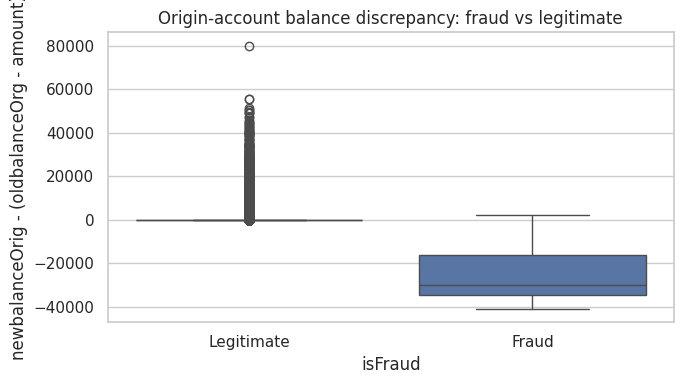

In [5]:
df["expected_new_balance"] = df["oldbalanceOrg"] - df["amount"]
df["balance_discrepancy"] = df["newbalanceOrig"] - df["expected_new_balance"]

fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=df, x="isFraud", y="balance_discrepancy", ax=ax)
ax.set_xticklabels(["Legitimate", "Fraud"])
ax.set_title("Origin-account balance discrepancy: fraud vs legitimate")
ax.set_ylabel("newbalanceOrig - (oldbalanceOrg - amount)")
plt.tight_layout()
plt.savefig("../reports/figures/balance_discrepancy.png", dpi=150)
plt.show()

## Takeaways

- Fraud is extremely rare relative to legitimate traffic — confirms the need
  for probabilistic risk scores over hard binary classification thresholds.
- Fraud is concentrated in specific transaction types, which will inform
  feature engineering in the preprocessing step.
- The origin-account balance discrepancy looks like a strong candidate
  feature for the Bayesian risk model.

**Next step:** `src/data/preprocessing.py` — build the feature engineering
pipeline and stratified train/test split (Commit 3).